# CS5489 - 机器学习
# 第 3c 讲 - 分类方法总结
### 香港城市大学 计算机科学系

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>本讲从实际建模角度总结分类：先处理特征和数据，再理解模型、损失、正则化与评估。</div>


# 大纲
1. 判别式线性分类器
2. 逻辑回归
3. 支持向量机（SVM）与核 SVM
4. 分类方法总结

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>3c 的重点不是新的分类算法，而是将 3a 和 3b 的模型放进完整机器学习流程中。</div>


In [1]:
# 环境设置
%matplotlib inline
import matplotlib_inline   # 环境设置 output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # 以较大尺寸显示图像
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'DejaVu Sans']  # 中文字体回退列表
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats

In [2]:
def drawstump(fdim, fthresh, fdir='gt', poscol=None, negcol=None, lw=2, ls='k-'):
    # fdim = 特征维度
    # fthresh = 阈值
    # fdir = 方向（gt 为大于，lt 为小于）
    
    if fdir == 'lt':
        # 交换颜色
        tmp = poscol
        poscol = negcol
        negcol = tmp
    
    # 假设 fdim=0
    polyxn = [fthresh, fthresh, -30, -30]
    polyyn = [30, -30, -30, 30]
    
    polyxp = [fthresh, fthresh, 30, 30]
    polyyp = [30, -30, -30, 30]
        
    # 填充正半空间或负半空间
    if (poscol):
        if fdim==0:
            plt.fill(polyxp, polyyp, poscol, alpha=0.2)
        else:
            plt.fill(polyyp, polyxp, poscol, alpha=0.2)            
    
    if (negcol):
        if fdim==0:
            plt.fill(polyxn, polyyn, negcol, alpha=0.2)
        else:
            plt.fill(polyyn, polyxn, negcol, alpha=0.2)

    # 绘制直线
    if fdim==0:
        plt.plot(polyxp[0:2], polyyp[0:2], ls, lw=lw)
    else:
        plt.plot(polyyp[0:2], polyxp[0:2], ls, lw=lw)

def drawplane(w, b=None, c=None, wlabel=None, poscol=None, negcol=None, lw=2, ls='k-'):
    # w^Tx + b = 0
    # w0 x0 + w1 x1 + b = 0
    # x1 = -w0/w1 x0 - b / w1

    # 或者
    # w^T (x-c) = 0 = w^Tx - w^Tc  --> b = -w^Tc
    if c != None:
        b = -sum(w*c)
    
    # 直线
    if (abs(w[0])>abs(w[1])):   # 竖直线
        x0 = array([-30,30])
        x1 = -w[0]/w[1] * x0 - b / w[1]
    else:                       # 水平线
        x1 = array([-30,30])
        x0 = -w[1]/w[0] * x1 - b / w[0]
    
    # 填充正半空间或负半空间
    if (poscol):
        polyx = [x0[0], x0[-1], x0[-1], x0[0]]
        polyy = [x1[0], x1[-1], x1[0], x1[0]]
        plt.fill(polyx, polyy, poscol, alpha=0.2)
    
    if (negcol):
        polyx = [x0[0], x0[-1], x0[0], x0[0]]
        polyy = [x1[0], x1[-1], x1[-1], x1[0]]
        plt.fill(polyx, polyy, negcol, alpha=0.2)
        
    # 绘制直线
    lineplt, = plt.plot(x0, x1, ls, lw=lw)

    # 向量 w
    if (wlabel):
        xp = array([0, -b/w[1]])
        xpw = xp+w
        plt.arrow(xp[0], xp[1], w[0], w[1], width=0.01)
        plt.text(xpw[0]-0.5, xpw[1], wlabel)
    return lineplt

In [3]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（变色鸢尾=1，弗吉尼亚鸢尾=2）

print(X.shape)

# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(100, 2)
(50, 2)
(50, 2)


In [4]:
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

axbox = [2.5, 7, 1.5, 4]



# 特征预处理
- 某些分类器（如 SVM 和逻辑回归）对特征数值的尺度很敏感：
  - 数值较大的特征维度可能在目标函数中占据主导地位。
- 通常在学习分类器前，对每个特征维度进行**标准化**或**归一化**。
  - 下面介绍两种方法。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>基于距离、内积或权重惩罚的模型通常会受特征尺度影响。</div>


- **方法 1：**缩放每个特征维度，使均值为 0、方差为 1。
  - $\tilde{x}_d = \frac{1}{s}(x_d-m)$
  - $s$ 是特征值的标准差。
  - $m$ 是特征值的均值。
- **注意：缩放参数必须只使用训练集估计！**
  - 对测试集应用与训练集完全相同的缩放方式。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>必须先划分训练集和测试集，再用训练集拟合缩放器，否则会发生数据泄漏。</div>


In [5]:
# 使用 Iris 数据
scaler = preprocessing.StandardScaler()  # 创建缩放器
trainXn = scaler.fit_transform(trainX)   # 使用训练数据拟合缩放参数
testXn  = scaler.transform(testX)        # 将相同缩放参数应用于测试数据

In [6]:
nfig1 = plt.figure(figsize=(9,4))
axbox2 = [-3, 3, -3, 3]

plt.subplot(1,2,1)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.axis(axbox); plt.grid(True)
plt.axis('equal')
plt.title("未归一化的特征")

plt.subplot(1,2,2)
plt.scatter(trainXn[:,0], trainXn[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.axis(axbox2); plt.grid(True)
plt.axis('equal')
plt.title("标准化后的特征")
plt.close()

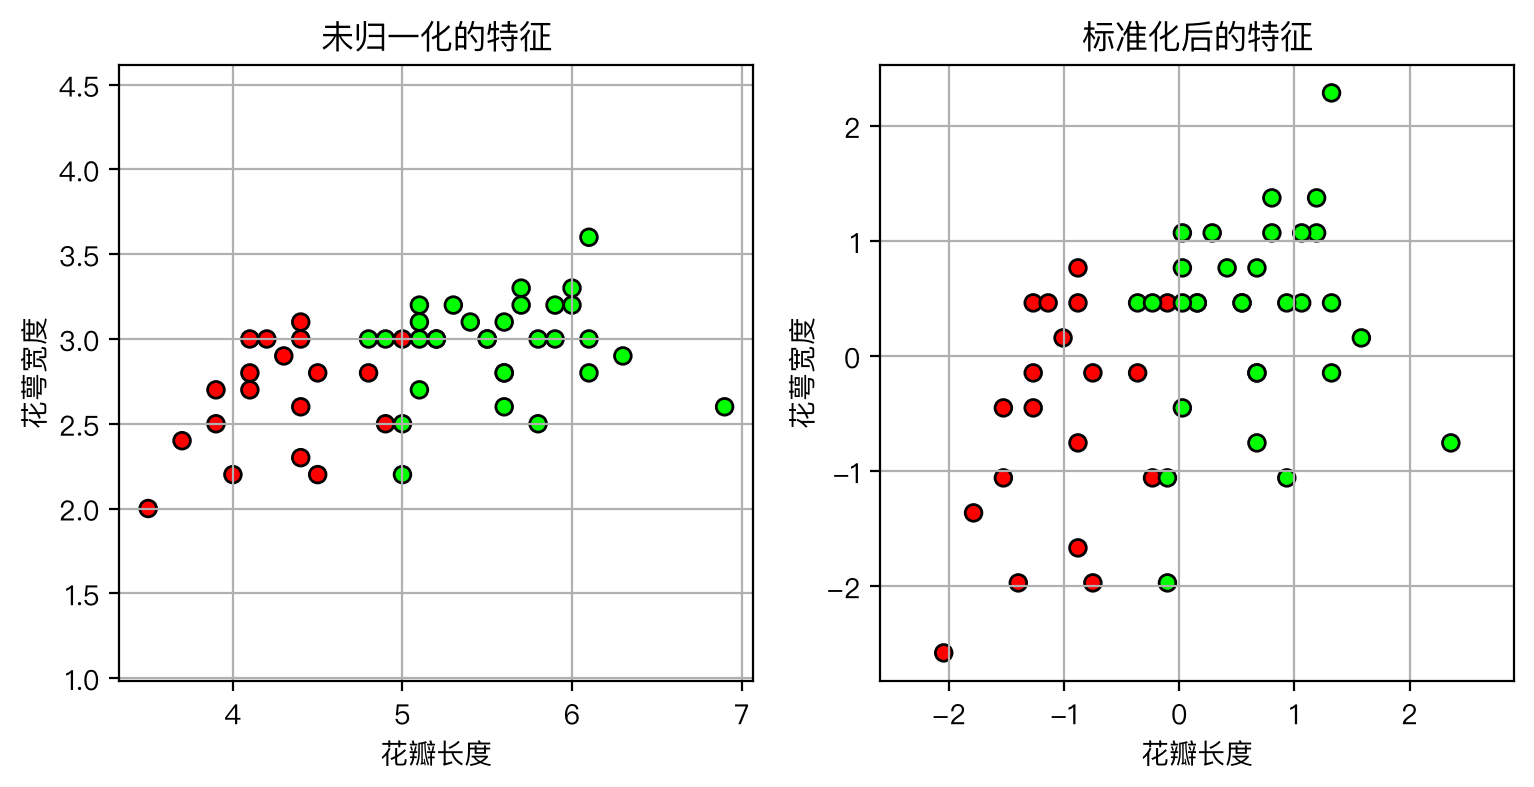

In [7]:
nfig1

- **方法 2：**将特征缩放到固定范围 $[-1,1]$。
  - $\tilde{x}_d = 2*(x_d - \min) / (\max-\min) - 1$
  - $\max$ 和 $\min$ 分别是特征在训练集中的最大值和最小值。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>Min-Max 缩放依赖训练集极值，因此测试值超出训练范围时，变换后的值也可能超出 [-1, 1]。</div>


In [8]:
# 使用 Iris 数据
scaler = preprocessing.MinMaxScaler(feature_range=(-1,1))    # 创建缩放器
trainXn = scaler.fit_transform(trainX)   # 使用训练数据拟合缩放参数
testXn  = scaler.transform(testX)        # 将相同缩放参数应用于测试数据

In [9]:
nfig2 = plt.figure(figsize=(9,4))
axbox2 = [-1, 1, -1, 1]

plt.subplot(1,2,1)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')

plt.axis(axbox); plt.grid(True)
plt.axis('equal')
plt.title("未归一化的特征")

plt.subplot(1,2,2)
plt.scatter(trainXn[:,0], trainXn[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.axis(axbox2); plt.grid(True)
plt.axis('equal')
plt.title("归一化到 [-1,1] 的特征")
plt.close()

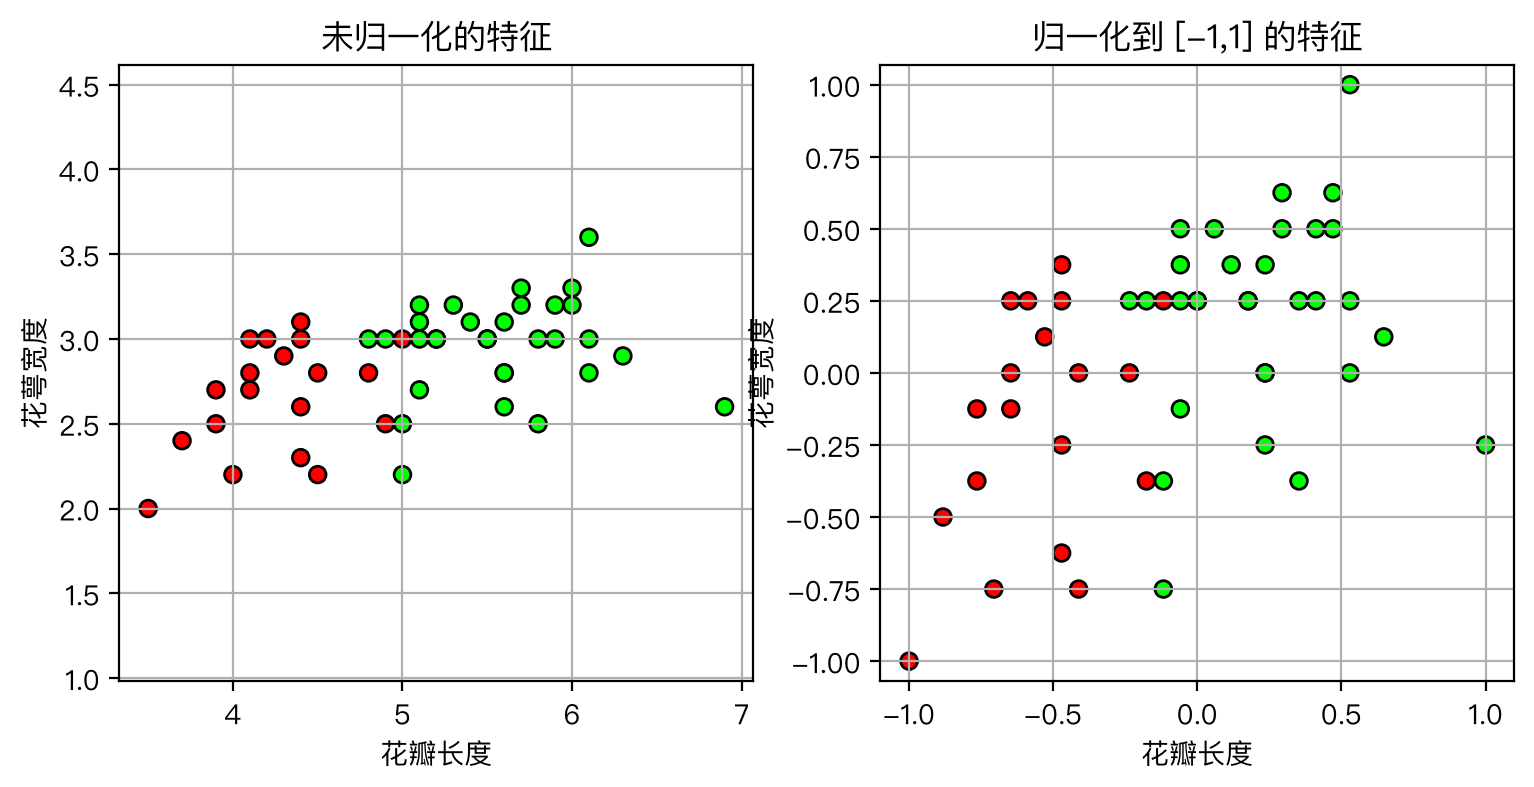

In [10]:
nfig2

# 数据表示与特征工程
- 如何将数据表示为数值向量？
  - 将数据编码成特征向量时，这种表示方式应具有合理意义。
  - 特征向量之间的内积和距离，应能反映原始数据的实际关系。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>特征表示决定了模型看到的相似性与结构，因此往往与分类器本身同样重要。</div>


- 类别变量
  - 例如，$x$ 有猫、狗、马三个可能的类别。
  - 我们可能尝试将它们分别编码为 $x=0$、$x=1$ 和 $x=2$。
    - 假设两个数据点分别是猫和马，那么它们编码后的乘积等于 2 究竟有什么意义？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>将无顺序类别编码成整数会人为引入大小、间距和乘积关系。</div>


# One-hot 编码
- 将一个类别变量编码为由 0 和 1 组成的向量：
  - 如果共有 $K$ 个类别，编码向量就有 $K$ 维。
- 示例：
  - 猫 → `[1, 0, 0]`
  - 狗 → `[0, 1, 0]`
  - 马 → `[0, 0, 1]`

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>One-hot 不对无序类别施加数值顺序，但类别很多时会产生高维稀疏特征。</div>


In [11]:
# one-hot 编码示例
X = [['cat'], ['dog'], ['cat'], ['bird'], ['dog']]  # 每行是一个样本
ohe = preprocessing.OneHotEncoder(sparse_output=False)
ohe.fit(X)         # 学习类别到 one-hot 向量的映射
print(ohe.categories_)
ohe.transform(X)   # 转换为 one-hot 编码

[array(['bird', 'cat', 'dog'], dtype=object)]


array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

# 分箱
- 将连续实数编码为由 0 和 1 组成的向量：
  - 先根据区间将每个特征值分配到某个箱中，再对箱号使用 one-hot 编码。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>分箱能表达分段非线性，但箱边界和箱数是需要调整的建模选择。</div>


In [12]:
# 示例
X = [[-3], [0.5], [1.5], [2.5]]  # 数据
bins = [-2,-1,0,1,2]      # 定义分箱边界

# 将数值映射为箱号
Xbins = digitize(X, bins=bins)   

# 将箱号（0到5）映射为 0-1 向量
ohe = preprocessing.OneHotEncoder(categories=[arange(6)], sparse_output=False)
ohe.fit(Xbins)
ohe.transform(Xbins)

array([[1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]])

# 数据变换：多项式
- 使用多项式表示特征之间的交互作用。
- 示例：
  - 二次多项式可以建模成对交互：
    - $[x_1, x_2] \rightarrow [x_1^2, x_1 x_2, x_2^2]$
  - 也可以将不同次数的项组合在一起：
    - $[x_1, x_2] \rightarrow [1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>加入交互项后，线性分类器也能在原始特征空间中表达某些非线性边界。</div>


In [13]:
X = [[0,1], [1,2], [3,4]]
pf = preprocessing.PolynomialFeatures(degree=2)
pf.fit(X)
pf.transform(X) 

array([[ 1.,  0.,  1.,  0.,  0.,  1.],
       [ 1.,  1.,  2.,  1.,  2.,  4.],
       [ 1.,  3.,  4.,  9., 12., 16.]])

# 数据变换：单变量非线性变换
- 对单个特征应用非线性变换：
  - 例如，将 $x$ 变换为 $\log(x)$。
  - 当 $x$ 的动态范围很大时，这类变换很有用。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>对数变换可压缩长尾特征的动态范围，但必须先处理零值和负值。</div>


# 数据类别不平衡
- 某些分类任务的数据存在类别不平衡：
  - 某个类别的样本数量远多于另一个类别。
- **示例：**信用卡欺诈检测。
  - 信用卡欺诈非常少见：
    - 可能只有 50 个欺诈样本，却有 5000 个正常交易样本。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>在罕见事件检测中，单看总准确率可能严重误导；应同时关注召回率、精确率等指标。</div>


In [14]:
# 生成随机数据
X,Y = datasets.make_blobs(n_samples=200, 
         centers=[[0,0]], cluster_std=2, n_features=2, random_state=4487)
X2,Y2 = datasets.make_blobs(n_samples=20, 
         centers=[[3,3]], cluster_std=0.5, n_features=2, random_state=4487)

X = r_[X,X2]
Y = r_[Y,Y2+1]

udatafig = plt.figure()
plt.scatter(X[:,0],X[:,1],c=Y,cmap=mycmap, edgecolors='k')
plt.grid(True)
plt.title('类别 0：200 个样本；类别 1：20 个样本')
plt.close()

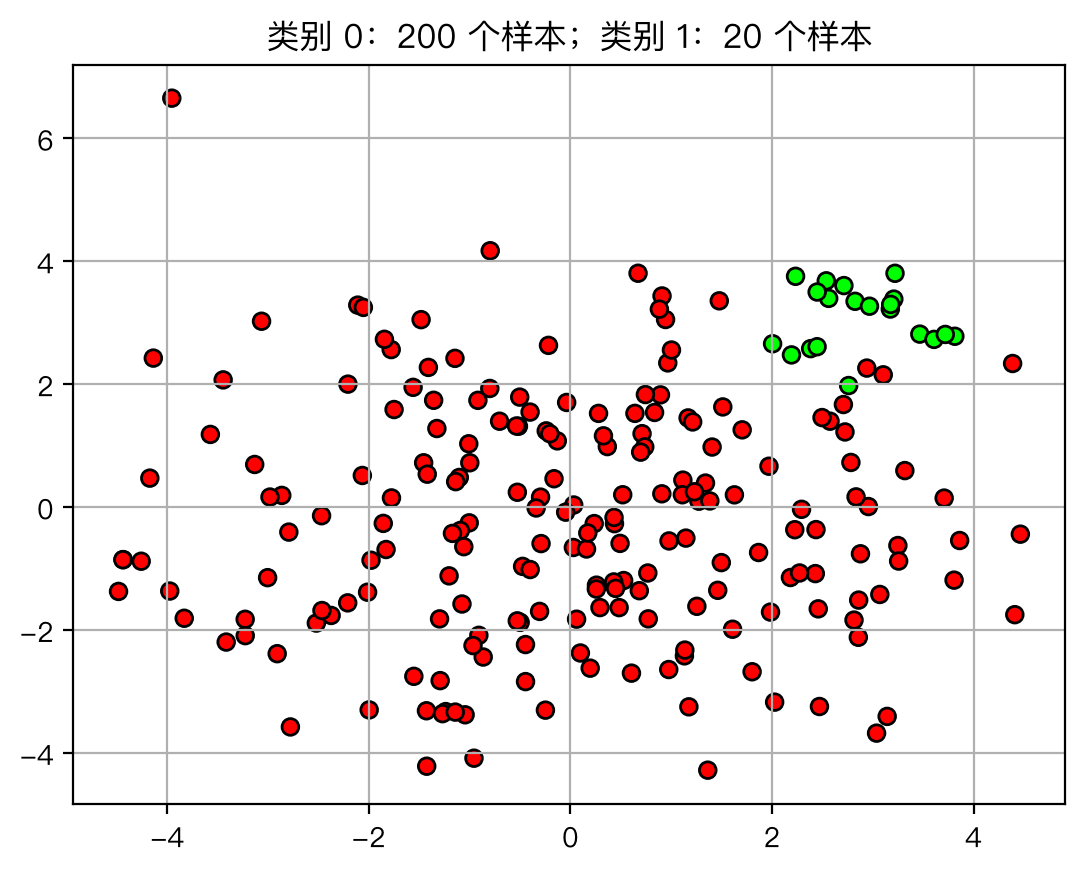

In [15]:
udatafig

- 数据类别不平衡可能导致分类器训练出现问题：
  - 分类器会更关注样本数量较多的类别。
  - 决策边界会被推向样本数量较少的类别。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>多数类样本对总损失的贡献更大，因而可能将决策边界压向少数类。</div>


In [16]:
clf = svm.SVC(kernel='linear', C=10)
clf.fit(X, Y)

udatafig1 = plt.figure()
plt.scatter(X[:,0],X[:,1],c=Y,cmap=mycmap, edgecolors='k')

w = clf.coef_[0]
b = clf.intercept_[0]
l1 = drawplane(w, b, lw=2, ls='k-')
plt.legend((l1,), ('SVM 决策边界',), fontsize=9)
plt.axis([-6, 7, -6, 7])
plt.grid(True)
plt.close()

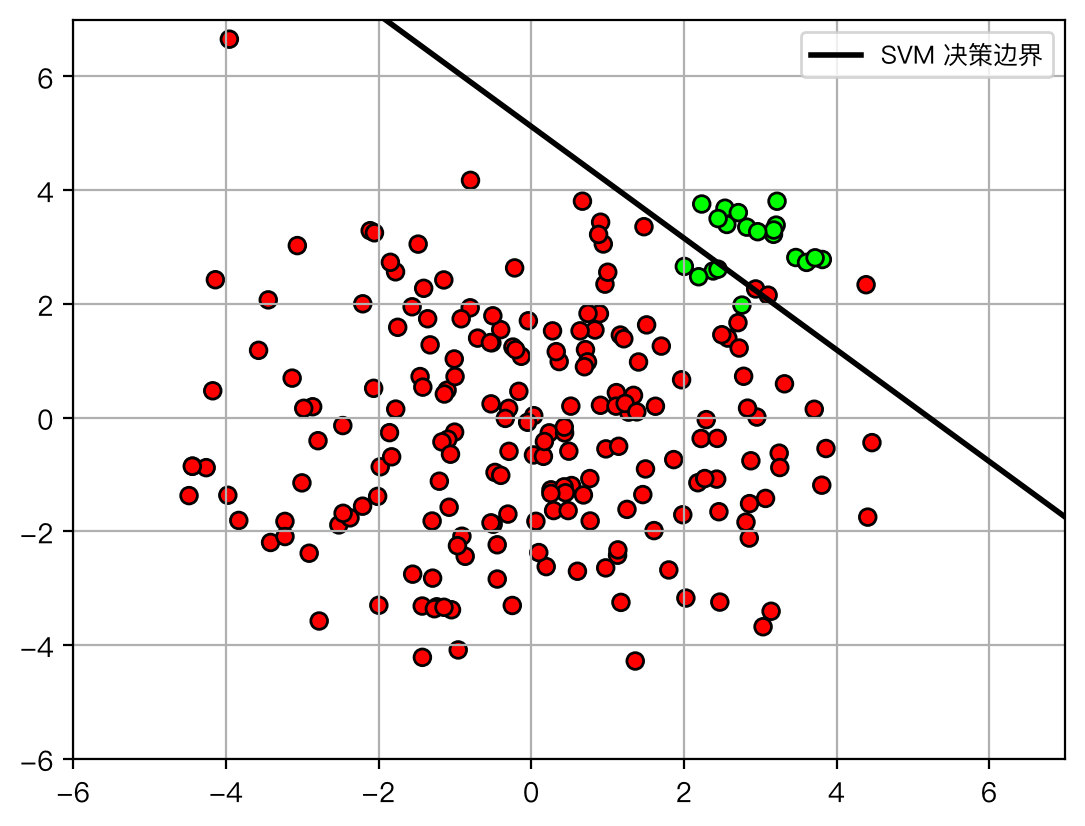

In [17]:
udatafig1

- **解决方法：**训练时对不同类别应用不同权重。
  - 可以让类别权重与该类别的样本数量成反比。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>自动平衡权重通常与类别频数成反比，但最终还要根据业务代价和验证结果调整。</div>


In [18]:
clfw = svm.SVC(kernel='linear', C=10,  class_weight='balanced')
clfw.fit(X, Y)

print("类别权重 =", clfw.class_weight_)

类别权重 = [0.55 5.5 ]


In [19]:
udatafig2 = plt.figure()
plt.scatter(X[:,0],X[:,1],c=Y,cmap=mycmap, edgecolors='k')

w = clf.coef_[0]
b = clf.intercept_[0]
ww = clfw.coef_[0]
bw = clfw.intercept_[0]
l1 = drawplane(w, b, lw=2, ls='k--')
l2 = drawplane(ww, bw, lw=2, ls='k-')
plt.legend((l1,l2), ('未加权', '已加权'), fontsize=9)
plt.axis([-6, 7, -6, 7])
plt.grid(True)
plt.close()

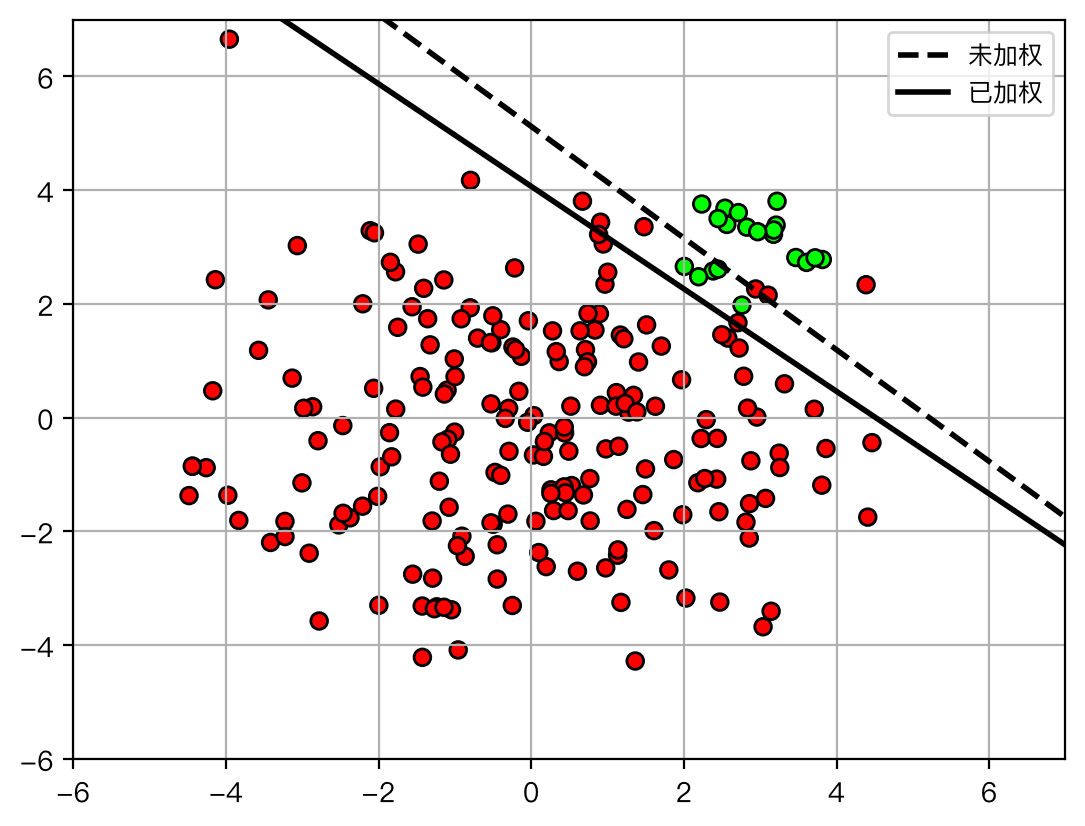

In [20]:
udatafig2

# 分类错误代价不对称
- 在某些任务中，对某些类别产生的错误难以接受。
- **示例：**区分垃圾邮件和正常邮件。
  - 正常邮件应尽量不被错误标记为垃圾邮件。
    - 相比之下，少量垃圾邮件被当作正常邮件可能更容易接受。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>这里的“不平衡”指错误代价不对称，与上一节的样本数量不平衡不完全相同。</div>


In [21]:
X,Y = datasets.make_blobs(n_samples=200, 
         centers=[[-3,0],[3,0]], cluster_std=2, n_features=2, random_state=447)
udatafig3 = plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.grid(True)
plt.close()

clf = svm.SVC(kernel='linear', C=10)
clf.fit(X, Y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


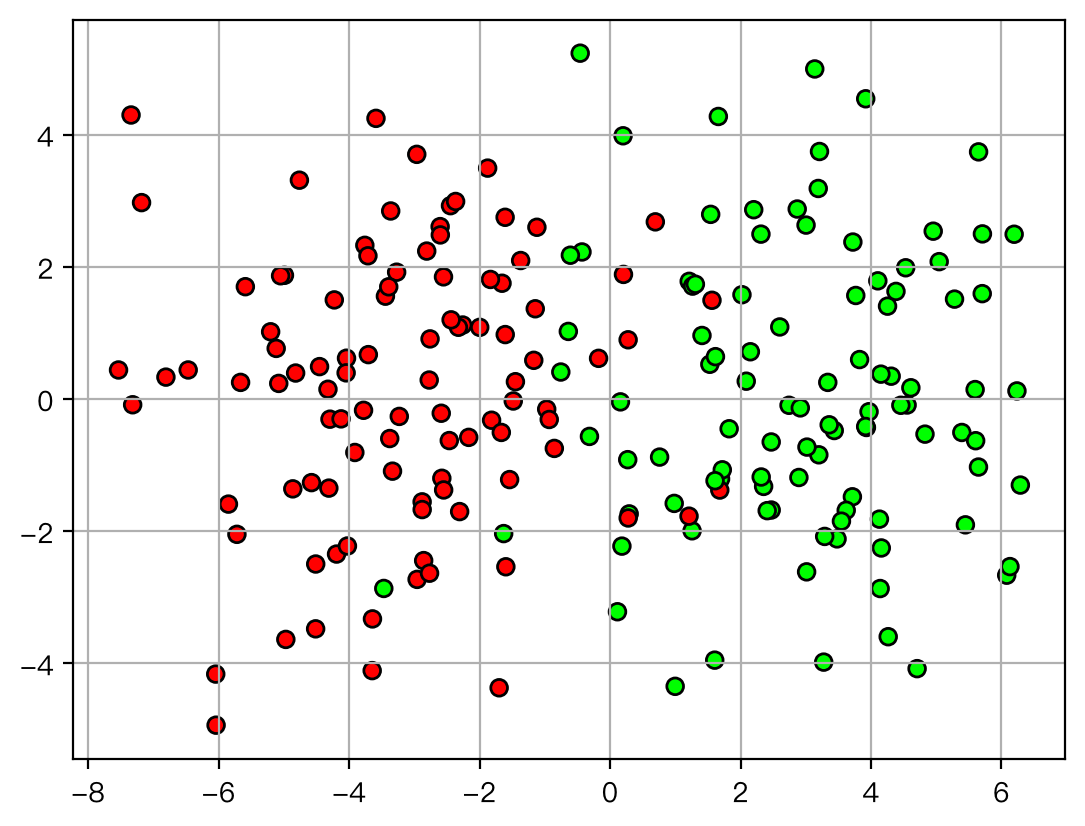

In [22]:
udatafig3

……

- 可以使用类别权重让分类器更关注某些类别：
  - 例如，给正常邮件类别设定比垃圾邮件更高的权重。
    - 分类器将尽量正确分类所有正常邮件，代价是容忍更多垃圾邮件被错分。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>调整类别权重会改变决策边界，本质上是让某类错误在目标函数中付出更大代价。</div>


In [23]:
# 字典（键，值）=（类别名称，类别权重）
cw = {0: 0.2, 
      1:  5}  # 类别 1 的重要性是类别 0 的 25 倍

clfw = svm.SVC(kernel='linear', C=10,  class_weight=cw)
clfw.fit(X, Y);

In [24]:
udatafig4 = plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.grid(True)

w = clf.coef_[0]
b = clf.intercept_[0]
ww = clfw.coef_[0]
bw = clfw.intercept_[0]
l1 = drawplane(w, b, lw=2, ls='k--')
l2 = drawplane(ww, bw, lw=2, ls='k-')
plt.legend((l1,l2), ('未加权', '已加权'), fontsize=9)
plt.axis([-10, 8, -6, 6])

plt.close()

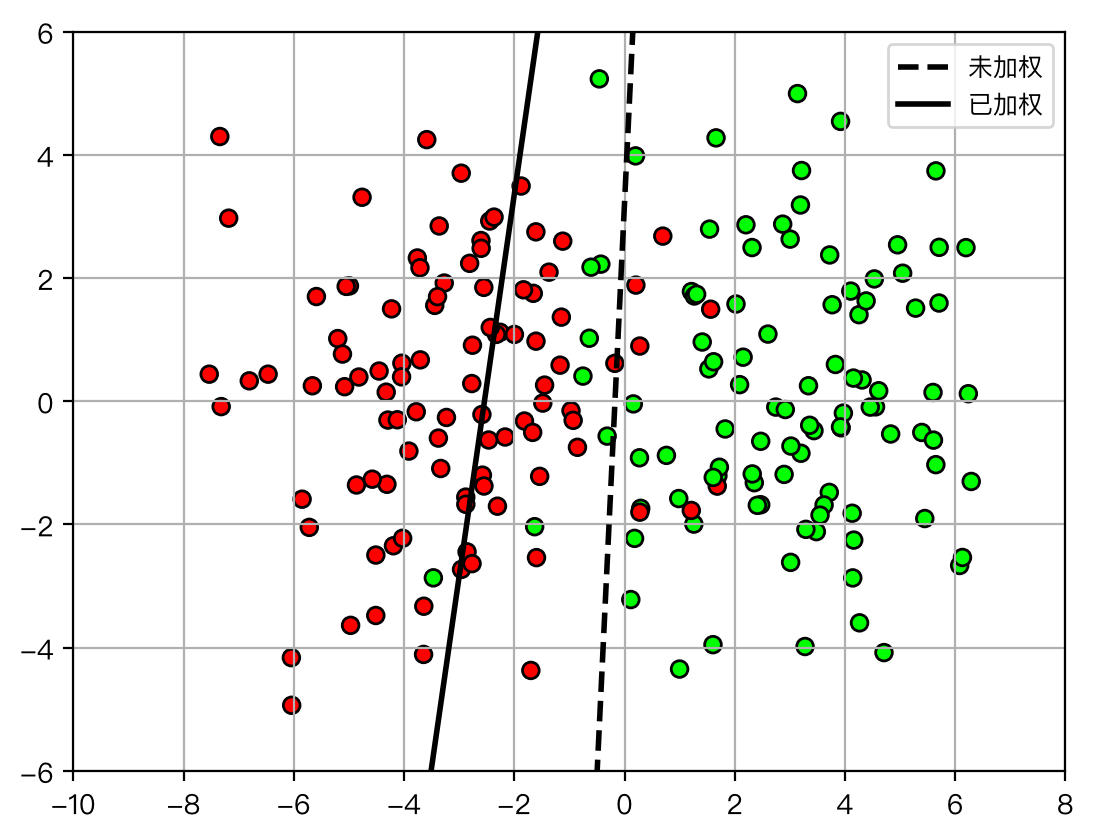

In [25]:
udatafig4

# 分类方法总结

- **分类任务**
  - 观测 $\mathbf{x}$：通常是实数特征向量，$\mathbf{x}\in\mathbb{R}^d$。
  - 类别 $y$：取自某个可能类别的集合，例如 ${\cal Y}=\{0,1\}$。
  - **目标：**给定观测 $\mathbf{x}$，预测它的类别 $y$。

<table style="font-size:9pt;">
<tr>
<th>名称</th><th>类型</th><th>类别</th><th>决策函数</th><th>训练方式</th><th>优点</th><th>缺点</th>
</tr>
<tr>
<td>贝叶斯分类器</td><td>生成式</td><td>多类</td><td>非线性</td><td>通过最大化数据似然估计类条件密度 p(x|y)。</td><td>小数据下可表现良好；原生支持多类；概率模型正确时可达到最小错误概率。</td><td>依赖数据真正符合所假设的类条件分布。</td>
</tr>
<tr>
<td>逻辑回归</td><td>判别式</td><td>二类</td><td>线性</td><td>最大化条件概率 p(y|x) 下的数据似然。</td><td>概率通常校准较好；训练高效。</td><td>决策边界为线性；对 C 参数敏感。</td>
</tr>
<tr>
<td>支持向量机（SVM）</td><td>判别式</td><td>二类</td><td>线性</td><td>最大化决策面与最近样本之间的间隔。</td><td>适合高维数据；泛化表现通常良好。</td><td>决策边界为线性；对 C 参数敏感。</td>
</tr>
<tr>
<td>核 SVM</td><td>判别式</td><td>二类</td><td>非线性，由核函数决定</td><td>最大化间隔。</td><td>可得到非线性决策边界；选择合适核时可用于非向量数据。</td><td>对核函数及其超参数敏感；在大数据集上内存开销较高。</td>
</tr>
</table>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>没有单一模型在所有维度上占优：生成假设、概率输出、非线性能力和计算成本都需要权衡。</div>


# 损失函数
- 不同分类器使用不同的损失函数，而损失函数会影响模型如何学习。
  - 定义 $z_i = y_i f(\mathbf{x}_i)$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>逻辑回对所有有限正间隔样本仍有非零损失；SVM 合页损失对正确间隔外样本的损失为零。</div>


In [26]:
z = linspace(-6,6,100)
logloss = log(1+exp(-z)) / log(2)
hingeloss = maximum(0, 1-z)
exploss = exp(-z)
lossfig = plt.figure()

plt.plot([0,0], [0,9], 'k--')
plt.text(0,8.5, "分类错误 $\\Leftarrow$ ", ha='right', weight='bold')
plt.text(0,8.5, " $\Rightarrow$ 分类正确", ha='left', weight='bold')

plt.plot(z,hingeloss, 'b-', label='合页损失（SVM）')
plt.plot(z,logloss, 'r-', label='逻辑损失（逻辑回归）')
# plt.plot(z,exploss, 'g-', label='指数损失（AdaBoost）')
plt.axis([-6,6,0,9]); plt.grid(True)
plt.xlabel('$z_i$');
plt.ylabel('损失')
plt.legend(loc='right', fontsize=10)
plt.title('损失函数')
plt.close()

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


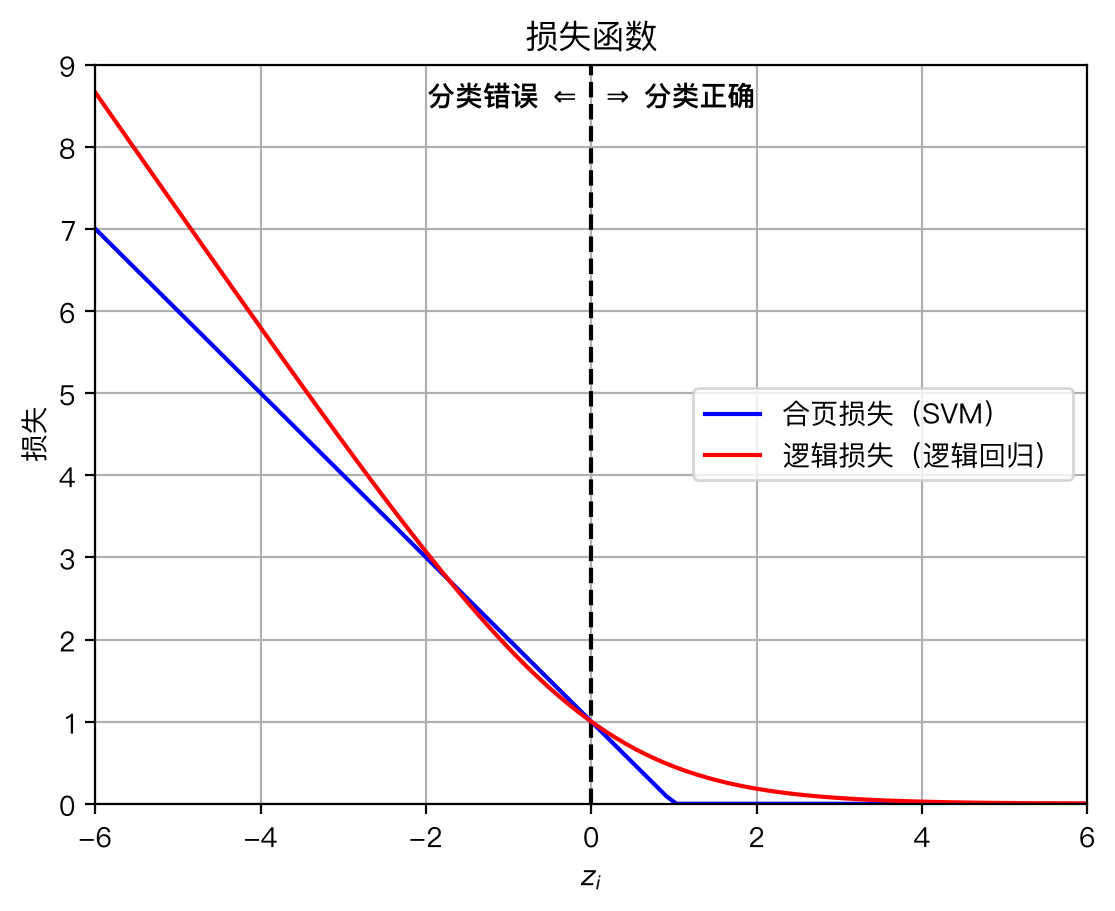

In [27]:
lossfig

# 正则化与过拟合
- 某些模型使用额外项防止对训练数据过拟合：
  - 这可以改善模型对新数据的**泛化**能力。
- 通常有一个超参数用于控制正则化的影响：
  - 应使用训练集上的交叉验证选择该参数。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>正则化不是让训练损失最小，而是希望通过限制复杂度降低未见数据上的误差。</div>


In [28]:
X,Y = datasets.make_blobs(n_samples=100, 
         centers=[[-3,0],[3,0]], cluster_std=1.5, n_features=2, random_state=447)
udatafig3 = plt.figure()
axbox = [-10,8,-6,6]
xr = [linspace(axbox[0], axbox[1], 50), linspace(axbox[2], axbox[3], 50)]

Cs = [0.1, 10, 100]
clf={}

ofig = plt.figure(figsize=(9,3))
for i,C in enumerate(Cs):
    clf[C] = svm.SVC(kernel='rbf', C=C, gamma=0.05)
    clf[C].fit(X, Y)
    
    # 创建用于计算决策得分的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    score = clf[C].decision_function(allpts).reshape(xgrid0.shape)

    cmap = ([1,0,0], [1,0.7,0.7], [0.7,1,0.7], [0,1,0])
    
    plt.subplot(1,len(Cs),i+1)
    plt.contourf(xr[0], xr[1], score, colors=cmap, 
             levels=[-1000, -1, 0, 1, 1000], alpha=0.3)
    plt.contour(xr[0], xr[1], score, levels=[-1, 1], linewidths=1, linestyles='dashed', colors='k')
    plt.contour(xr[0], xr[1], score, levels=[0], linestyles='solid', colors='k')

    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    
    #plt.plot(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
    #         'ko',fillstyle='none', markeredgewidth=2)
    plt.axis(axbox); plt.grid(True)
    plt.title('C='+str(C))
plt.close()

<Figure size 640x480 with 0 Axes>

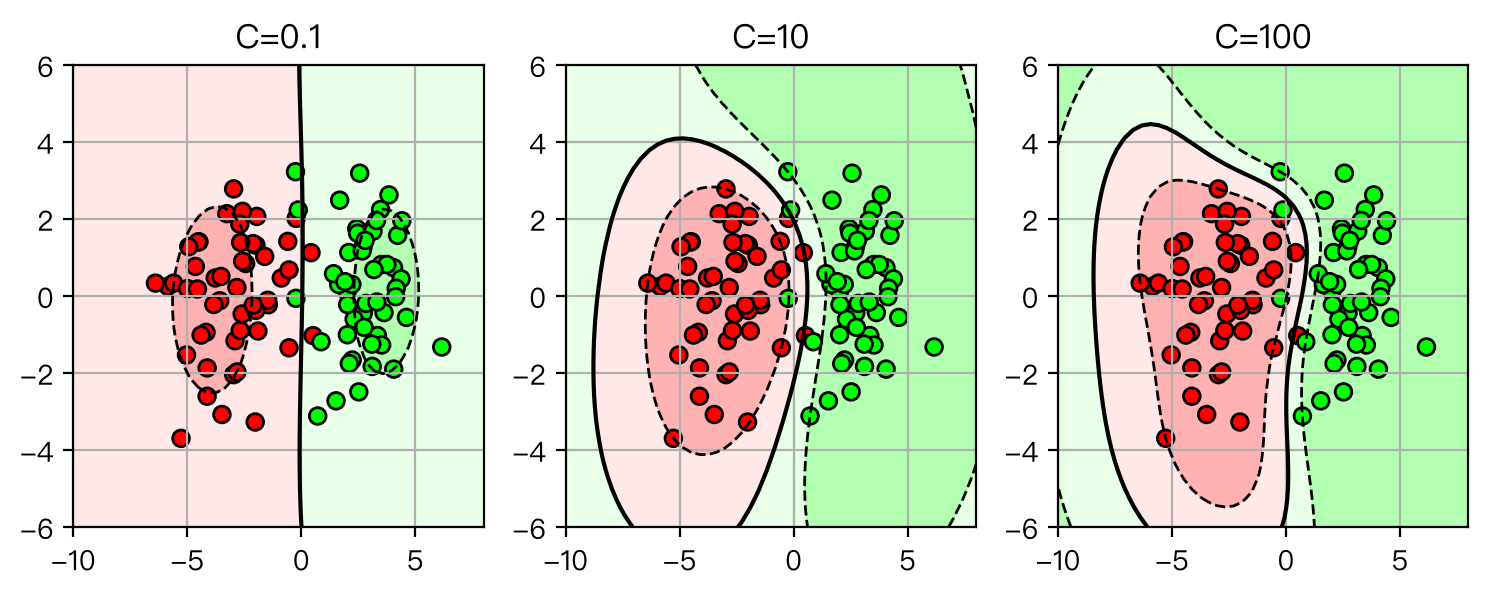

In [29]:
ofig

# 结构风险最小化
- 这是一个平衡数据拟合和模型复杂度的通用框架。
- 许多学习问题都可写成数据拟合项与正则化项的组合：
$$f^* = \mathop{\mathrm{argmin}}_{f} \sum_i L(y_i, f(\mathbf{x}_i)) + \lambda \Omega(f)$$
  - 假设 $f$ 取自某一函数类，例如线性函数 $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x}+b$。
  - $L$ 是损失函数，例如逻辑损失。
  - $\Omega$ 是对 $f$ 的正则化函数，例如 $||\mathbf{w}||^2$。
  - $\lambda$ 是数据拟合和模型复杂度之间的权衡参数，例如 $1/C$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>这个统一形式可用“经验风险＋复杂度惩罚”记忆；权衡参数需用交叉验证选择。</div>


# 其他要点
- **多类分类**
  - 可以使用“一对其余”方案将二元分类器扩展到多类。
- **特征归一化**
  - 对每个特征维度进行归一化，避免数值范围较大的特征主导优化过程。
- **数据类别不平衡**
  - 如果某个类别的数据更多，可对各类应用权重以平衡训练目标。
- **分类错误代价不对称**
  - 某些类别上的错误可能更加严重。
  - 可以提高重要类别的权重，使分类器优先减少该类别上的错误。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>一个完整的分类流程需同时考虑多类策略、特征尺度、样本比例和错误代价。</div>


# 应用
- 网页文档分类、垃圾邮件分类。
- 人脸性别识别、人脸检测、手写数字分类。

# 特征
- 特征的选择非常重要！
  - 使用无信息的特征可能会干扰分类器。
  - 应利用领域知识选择最有效的数据特征。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>模型只能利用输入特征中包含的信息；优质特征往往比一味更换分类器更有价值。</div>


# 哪一种分类器最好？
- Wolpert 和 Macready 的**“没有免费午餐”定理**：

> 如果一种算法在某一类问题上表现很好，那么代价必然是它在其余问题集合上的表现有所下降。

- 换句话说，不存在对所有任务都最好的分类器；最优选择取决于具体问题。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>“没有免费午餐”不是说算法无法比较，而是说比较必须绑定具体数据、指标、约束和任务。</div>


# 本讲总体总结

1. **正确的数据处理是分类的前提。** 特征缩放、编码器和其他变换参数都必须只在训练集上拟合，再原样应用到验证集和测试集。
2. **特征表示会影响模型看到的结构。** One-hot 编码适合无序类别，分箱能表达分段关系，多项式特征能表达交互与非线性，对数变换能压缩过大的动态范围。
3. **数据类别不平衡与错误代价不对称是两个不同问题。** 前者源于各类样本数量差异，后者源于不同错误的现实损失不同；两者都可通过类别权重影响训练。
4. **评估指标必须匹配任务。** 在罕见事件检测中，总准确率可能没有意义，应结合精确率、召回率以及具体错误代价。
5. **贝叶斯分类器、逻辑回归和 SVM 的建模原则不同。** 贝叶斯方法学习类条件分布，逻辑回归学习后验概率，SVM 则追求最大间隔。
6. **损失函数决定哪些样本会如何影响训练。** 逻辑损失平滑地惩罚样本，合页损失对正确间隔之外的样本不再惩罚。
7. **正则化用于控制模型复杂度。** 目标不是只追求训练集表现，而是提高对未见数据的泛化能力。
8. **结构风险最小化统一了数据拟合与模型复杂度。** 一个典型学习目标可以理解为“总损失＋复杂度惩罚”，两者的权衡由超参数控制。
9. **超参数应使用交叉验证选择。** 测试集必须保持独立，只在整个建模方案确定后进行最终评估。
10. **不存在适用于所有问题的最佳分类器。** 模型的选择应结合数据分布、特征质量、非线性程度、概率输出需求、数据规模和业务代价。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.8em;"><b>小结：</b>一个可靠的分类系统不仅是一个分类器，而是由无泄漏的数据处理、有意义的特征、合适的损失和正则化、正确的评估指标以及交叉验证共同构成的。</div>
